# Lab 5 — FeatureTools Auto Feature Engineering

**Day 04 · Distance-Based ML & MLOps · Cisco AI/ML Training**

---

## Goals

1. Build a FeatureTools **EntitySet** from the loans table.
2. Run **Deep Feature Synthesis (DFS)** with `max_depth=1`.
3. Inspect the engineered **feature matrix** shape and column names.
4. Rank auto-generated features by **|correlation|** with `default`.

> **Quick check:** shape **(1000, 6)** · **6** engineered features · top corr = **int_rate** (~0.21)

**Data:** **1000** loans from `lending_club_sample.csv`

## Deep Feature Synthesis (DFS) in one slide

FeatureTools automates feature engineering by applying **primitives** (sum, mean, count, etc.) across entities in an **EntitySet**.

| Concept | This lab |
|---------|----------|
| **EntitySet** | One table: `loans` indexed by `loan_id` |
| **DFS** | `ft.dfs(..., max_depth=1)` — one hop of transformations |
| **Output** | `feature_matrix` (1000 rows) + `feature_defs` (column recipes) |

## FeatureTools vs hand-picked features (Day 3)

| Approach | Pros | Cons |
|----------|------|------|
| Hand-picked | Interpretable, fast | Misses interactions |
| DFS | Discovers transforms automatically | Needs review before production |

---

## 1. Load loans and select DFS columns

In [1]:
from pathlib import Path

import pandas as pd

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]

import featuretools as ft
from IPython.display import display

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
dfs_cols = [
    "loan_id",
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "installment",
    "default",
]

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
raw = pd.read_csv(LENDING_CLUB_CSV)
raw["default"] = raw["loan_status"].isin(DEFAULT_STATUSES).astype(int)
df = raw[dfs_cols].copy()
df["loan_id"] = df["loan_id"].astype(str)

print(f"input columns: {len(df.columns)}")
print(f"rows: {len(df)}")
display(df.head(3))

input columns: 7
rows: 1000


,loan_id,loan_amnt,int_rate,annual_inc,dti,installment,default
0,L000001,34498,14.50,35829,15.66,98.07,1
1,L000002,33265,6.75,105184,5.91,859.60,0
2,L000003,4012,6.48,139128,13.90,320.56,1


`loan_id` becomes the **index** for the entity. `default` stays in the frame so DFS can include it in the output matrix for correlation analysis.

### 1b. Input column dtypes

In [4]:
print(df.dtypes)
print(f"\nnull counts:\n{df.isna().sum()}")


loan_id         object
loan_amnt        int64
int_rate       float64
annual_inc       int64
dti            float64
installment    float64
default          int64
dtype: object

null counts:
loan_id        0
loan_amnt      0
int_rate       0
annual_inc     0
dti            0
installment    0
default        0
dtype: int64


### 1c. Default rate in DFS frame

In [5]:
print(f"default rate: {df['default'].mean():.4f}")


default rate: 0.4850


---

## 2. Build the EntitySet

In [6]:
es = ft.EntitySet(id="lending")
es = es.add_dataframe(
    dataframe_name="loans",
    dataframe=df,
    index="loan_id",
)

print(es)


Entityset: lending
  DataFrames:
    loans [Rows: 1000, Columns: 7]
  Relationships:
    No relationships


C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\.venv\Lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\.venv\Lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


### 2b. EntitySet structure

In [7]:
print("dataframes:", list(es.dataframe_dict.keys()))
print("loans shape:", es["loans"].shape)


dataframes: ['loans']
loans shape: (1000, 7)


---

## 3. Run Deep Feature Synthesis

In [8]:
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="loans",
    max_depth=1,
    verbose=False,
)

print("Lab 5 — FeatureTools auto FE")
print(f"engineered features: {len(feature_defs)}")
print(f"feature matrix shape: {feature_matrix.shape}")
display(feature_matrix.head(3))


Lab 5 — FeatureTools auto FE
engineered features: 6
feature matrix shape: (1000, 6)


,loan_amnt,int_rate,annual_inc,dti,installment,default
loan_id,,,,,,
L000001,34498,14.50,35829,15.66,98.07,1
L000002,33265,6.75,105184,5.91,859.60,0
L000003,4012,6.48,139128,13.90,320.56,1


### 3b. Column names in feature matrix

In [9]:
print("columns:", list(feature_matrix.columns))


columns: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'default']


---

## 4. Inspect feature definitions

In [10]:
def_names = [fd.get_name() for fd in feature_defs]
defs_df = pd.DataFrame({"feature": def_names})
display(defs_df)


,feature
0,loan_amnt
1,int_rate
2,annual_inc
3,dti
4,installment
5,default


Each `feature_def` records the **primitive** and input columns — useful for reproducing or auditing auto-generated features in production.

### 4b. Primitive types used

In [11]:
primitives = [type(fd).__name__ for fd in feature_defs]
print(pd.Series(primitives).value_counts())


# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

IdentityFeature    6
Name: count, dtype: int64
Value counts — long tail categories may be omitted.


---

## 5. Correlation with default

In [12]:
numeric_cols = [
    c for c in feature_matrix.columns
    if c != "default" and str(feature_matrix[c].dtype) != "category"
]
top_corr = (
    feature_matrix[numeric_cols + ["default"]]
    .corr(numeric_only=True)["default"]
    .drop("default", errors="ignore")
    .abs()
    .sort_values(ascending=False)
)

print("top |corr| with default (first 3):")
for name, val in top_corr.head(3).items():
    print(f"  {name}: {val:.4f}")

display(top_corr.head(5).to_frame("abs_corr").round(4))


top |corr| with default (first 3):
  int_rate: 0.2084
  dti: 0.1530
  installment: 0.0608


,abs_corr
int_rate,0.2084
dti,0.1530
installment,0.0608
annual_inc,0.0112
loan_amnt,0.0056


**int_rate** leads — consistent with Day 3 logistic regression where `int_rate` had the strongest positive coefficient.

### 5b. Signed correlation for top feature

In [13]:
signed = (
    feature_matrix[numeric_cols + ["default"]]
    .corr(numeric_only=True)["default"]
    .drop("default", errors="ignore")
)
print(f"int_rate signed corr: {signed['int_rate']:.4f}")


int_rate signed corr: 0.2084


---

## 6. Compare to hand-picked Day 3 features

In [14]:
hand_picked = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]
hand_corr = (
    raw[hand_picked + ["default"]]
    .corr(numeric_only=True)["default"]
    .drop("default")
    .abs()
    .sort_values(ascending=False)
)

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [15]:
compare = pd.DataFrame({
    "source": ["DFS top", "Hand-picked top"],
    "feature": [top_corr.index[0], hand_corr.index[0]],
    "abs_corr": [top_corr.iloc[0], hand_corr.iloc[0]],
})
display(compare.round(4))

,source,feature,abs_corr
0,DFS top,int_rate,0.2084
1,Hand-picked top,int_rate,0.2084


DFS surfaces the same signal domain experts chose — but on richer multi-table data it can discover interactions you'd miss manually.

### 6b. Full hand-picked ranking

In [16]:
display(hand_corr.to_frame("abs_corr").round(4))


,abs_corr
int_rate,0.2084
dti,0.1530
installment,0.0608
annual_inc,0.0112
loan_amnt,0.0056


---

## 7. Feature matrix statistics

In [17]:
display(feature_matrix.describe().round(2))


,loan_amnt,int_rate,annual_inc,dti,installment,default
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,18117.78,14.31,103132.76,19.71,463.44,0.48
std,9968.01,5.49,45192.41,8.47,244.77,0.50
min,1040.00,5.03,25107.00,5.03,51.15,0.00
25%,9173.50,9.52,63004.00,12.44,243.05,0.00
50%,18290.00,14.35,102884.00,19.30,451.08,0.00
75%,26676.25,19.20,141821.50,27.01,682.26,1.00
max,34999.00,23.99,179778.00,35.00,899.85,1.00


### 7b. Any missing values after DFS?

In [18]:
print(feature_matrix.isna().sum().sum(), "total nulls")


0 total nulls


---

## 8. What changes with `max_depth=2`?

With a single table, `max_depth=2` may add little. With **related tables** (borrowers, payments), deeper DFS creates cross-entity aggregations — the real power of FeatureTools.

### 8b. Row count sanity check

In [19]:
assert len(feature_matrix) == len(df) == 1000
print("DFS preserved all loan rows:", len(feature_matrix))


DFS preserved all loan rows: 1000


### 8c. Feature matrix dtypes

In [20]:
print(feature_matrix.dtypes)


loan_amnt        int64
int_rate       float64
annual_inc       int64
dti            float64
installment    float64
default          int64
dtype: object


### 8d. Scatter — int_rate vs default (top feature)

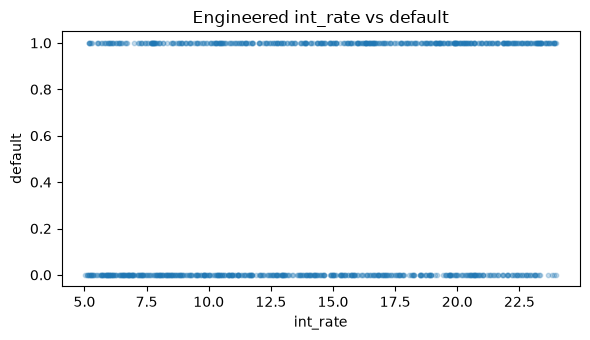

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(feature_matrix["int_rate"], feature_matrix["default"], alpha=0.25, s=10)
ax.set_xlabel("int_rate")
ax.set_ylabel("default")
ax.set_title("Engineered int_rate vs default")
plt.tight_layout()
plt.show()


### 8e. Save feature matrix (optional artifact)

In [22]:
# feature_matrix.to_parquet("dfs_features.parquet")
print("Feature matrix ready for downstream modeling pipelines.")


Feature matrix ready for downstream modeling pipelines.


---

## 9. Feature selection preview

Top correlated features are candidates for KNN or logistic models — always review for leakage.

In [23]:
top3 = top_corr.head(3).index.tolist()
print("Top 3 DFS features by |corr|:", top3)
subset = feature_matrix[top3 + ["default"]]
display(subset.corr(numeric_only=True).round(4))


Top 3 DFS features by |corr|: ['int_rate', 'dti', 'installment']


,int_rate,dti,installment,default
int_rate,1.0000,-0.0124,-0.0137,0.2084
dti,-0.0124,1.0000,-0.0483,0.1530
installment,-0.0137,-0.0483,1.0000,-0.0608
default,0.2084,0.1530,-0.0608,1.0000


### 9b. Drop default from modeling matrix

In [24]:
X_dfs = feature_matrix.drop(columns=["default"], errors="ignore")
print("Modeling matrix shape (no target):", X_dfs.shape)


Modeling matrix shape (no target): (1000, 5)


### 9c. Feature variance check

In [25]:
variance = X_dfs.var().sort_values(ascending=False)
display(variance.round(2).to_frame("variance"))


,variance
annual_inc,2.042353e+09
loan_amnt,9.936120e+07
installment,5.991324e+04
dti,7.173000e+01
int_rate,3.018000e+01


---

## 10. Try it yourself

Which engineered feature has the **second** highest |corr| with default?

In [26]:
# Your code here (optional)


In [27]:
second = top_corr.index[1]
print(f"Second highest |corr|: {second} = {top_corr.iloc[1]:.4f}")


Second highest |corr|: dti = 0.1530


---

## 11. Checkpoint summary

In [28]:
assert len(df.columns) == 7
assert len(feature_defs) == 6
assert feature_matrix.shape == (1000, 6)
assert top_corr.index[0] == "int_rate"
assert abs(top_corr.iloc[0] - 0.2084) < 0.02
print("Numbers match — you're good.")



Numbers match — you're good.


---

## Reflection

1. What new features might appear with `max_depth=2` or multiple related tables?
2. Why filter out categorical columns before correlation ranking?
3. Would you feed the DFS matrix directly into KNN without reviewing primitives?
